#### Objetivo:
Segmentar clientes en grupos homogéneos utilizando variables de comportamiento (RFM) para identificar perfiles y apoyar estrategias de retención.

## 1. Libreria

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Cargar dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/PI_LV/data/processed/clientes_churn_scored.csv')

In [3]:

from pathlib import Path

In [4]:
DATA_PATH = Path('../data/processed/clientes_churn_scored.csv')

if not DATA_PATH.exists():
    DATA_PATH = Path('/mnt/data/clientes_churn_scored.csv')

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(80355, 27)


,cliente_id_new,fecha_primera_compra,fecha_ultima_compra,recency,frequency,monetary,tenure_days,active_month_ratio,avg_ticket,std_ticket,...,ratio_descuento_sobre_venta,margen_pct,dias_promedio_vencimiento,flag_credito,churn_60,churn_70,churn_90,churn,score_churn,pred_churn
0,1027461,2024-05-08,2025-02-28,307,5,1970.18,296,0.300000,394.03600,256.588208,...,0.089847,0.514021,0.0,0.0,1,1,1,1,0.688902,1
1,1089134,2025-02-06,2025-12-31,1,20,17891.83,328,1.000000,894.59150,687.827867,...,0.175732,0.503229,0.0,0.0,0,0,0,0,0.144226,0
2,1089187,2024-02-19,2025-12-08,24,31,7418.34,658,0.782609,239.30129,180.339686,...,0.131741,0.440145,0.0,0.0,0,0,0,0,0.442597,1
3,1111859,2024-10-16,2025-12-18,14,20,3583.75,428,0.866667,179.18750,99.518539,...,0.162716,0.490562,0.0,0.0,0,0,0,0,0.201553,0
4,1133970,2024-04-08,2025-12-04,28,8,937.10,605,0.333333,117.13750,72.922652,...,0.136548,0.369825,0.0,0.0,0,0,0,0,0.744322,1


## 3. Seleccionar variables para clustering

In [5]:
features_cluster = [
    'frequency',
    'monetary',
    'avg_ticket',
    'active_month_ratio',
    'avg_days_between',
    'max_gap_days',
    'descuento_porc_promedio',
    'ratio_descuento_sobre_venta',
    'margen_pct',
    'dias_promedio_vencimiento',
    'total_galones',
    'tenure_days'
]

X = df[features_cluster].copy()

## 4. Transformar variables sesgadas

In [6]:
cols_skewed_cluster = [
    'frequency',
    'monetary',
    'avg_ticket',
    'total_galones',
    'tenure_days'
]

X_log = X.copy()
for col in cols_skewed_cluster:
    X_log[col] = np.log1p(X_log[col])

## 5. Escalar datos

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

Para la segmentación se seleccionaron variables conductuales, temporales, de valor y comerciales, evitando la inclusión de la variable objetivo de churn y de atributos demasiado cercanos a su definición operativa. De esta manera, la clusterización busca identificar perfiles naturales de clientes más allá del riesgo supervisado de abandono.

## 6. Elegir número de clusters

Elegir número de clusters (Elbow + Silhouette)

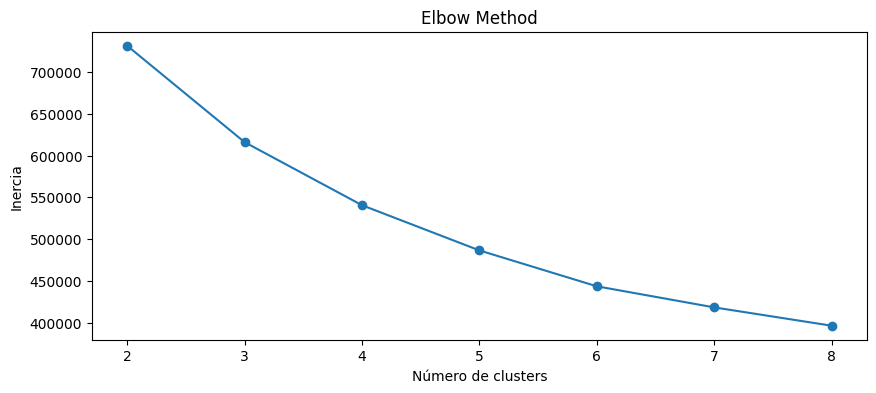

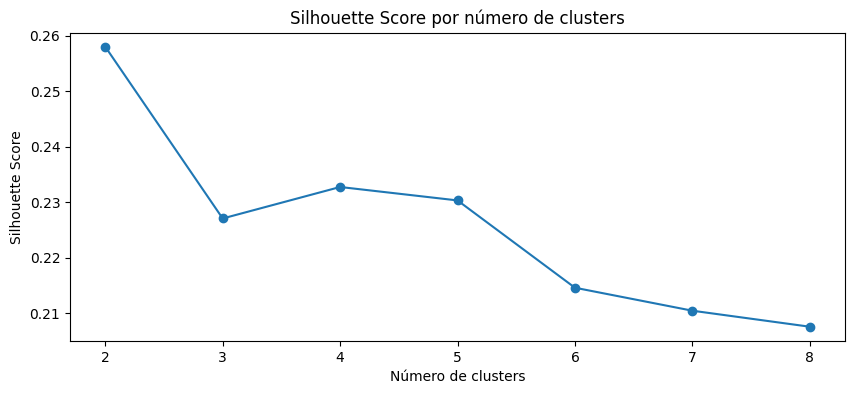

In [8]:
inertia = []
silhouette_scores = []

k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Elbow Method')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por número de clusters')
plt.show()

Aunque el mayor coeficiente de Silhouette se obtuvo con 2 clusters, se optó por 4 clusters por ofrecer un mejor equilibrio entre calidad estadística e interpretabilidad de negocio. El valor de Silhouette en 4 clusters se mantuvo en un rango aceptable, mientras que el método del codo mostró una reducción progresivamente menor de la inercia a partir de ese punto. Esta elección permite identificar segmentos más accionables para estrategias diferenciadas de retención.

## 7. Aplicar KMeans

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

## 8. Analizar clusters

In [10]:
cluster_summary = df.groupby('cluster')[features_cluster].mean().round(2)
cluster_summary

,frequency,monetary,avg_ticket,active_month_ratio,avg_days_between,max_gap_days,descuento_porc_promedio,ratio_descuento_sobre_venta,margen_pct,dias_promedio_vencimiento,total_galones,tenure_days
cluster,,,,,,,,,,,,
0,7.98,4132.79,670.85,0.29,148.64,327.09,6.51,0.08,0.49,2.82,96.79,700.82
1,6.23,1688.05,390.79,0.78,32.92,63.39,16.39,0.22,0.40,1.60,52.58,165.05
2,2.13,1270.08,852.89,0.95,10.54,15.16,4.48,0.05,0.50,1.64,29.34,27.21
3,39.28,41670.23,1227.52,0.66,35.01,133.17,8.39,0.10,0.49,11.05,980.75,958.36


In [11]:
df['cluster'].value_counts()

cluster
3    32137
0    19491
2    16171
1    12556
Name: count, dtype: int64

In [12]:
cluster_profile = (
    df.groupby('cluster')[features_cluster]
    .mean()
    .T
)

cluster_profile

cluster,0,1,2,3
frequency,7.976553,6.232160,2.126646,39.283038
monetary,4132.790617,1688.048787,1270.083643,41670.234618
avg_ticket,670.847064,390.792101,852.892779,1227.521346
active_month_ratio,0.289569,0.779317,0.951705,0.664519
avg_days_between,148.635040,32.916427,10.543729,35.009359
max_gap_days,327.085116,63.385075,15.158370,133.173134
descuento_porc_promedio,6.511629,16.385671,4.483210,8.391872
ratio_descuento_sobre_venta,0.080926,0.220647,0.053595,0.100881
margen_pct,0.491064,0.398183,0.495235,0.489813
dias_promedio_vencimiento,2.823315,1.596243,1.637940,11.052921


Cluster 3: clientes estratégicos de alto valor
Cluster 2: clientes recurrentes recientes y activos
Cluster 1: clientes sensibles al descuento
Cluster 0: clientes en deterioro o dormidos

## 10. Crear nombre de segmentos

In [13]:
def label_cluster(cluster):
    mapping = {
        0: 'En riesgo',
        1: 'Promocionales',
        2: 'Recurrentes',
        3: 'Estratégicos'
    }
    return mapping.get(cluster, 'Sin etiqueta')

df['segmento'] = df['cluster'].map(label_cluster)

Las etiquetas de los clusters se definieron con enfoque comercial y criterio interpretativo, considerando el comportamiento predominante de cada grupo en términos de valor, recurrencia, sensibilidad promocional y señales de deterioro. Por ello, los segmentos fueron denominados Estratégicos, Recurrentes, Promocionales y En riesgo

## 11. Distribución de segmentos

In [14]:
df['segmento'].value_counts()

segmento
Estratégicos     32137
En riesgo        19491
Recurrentes      16171
Promocionales    12556
Name: count, dtype: int64

Insight:

La segmentación permitió identificar cuatro perfiles comerciales con comportamientos claramente diferenciados frente al churn. El segmento Recurrentes concentra la mayor proporción de churn, seguido por En riesgo y Promocionales, mientras que Estratégicos presenta la menor incidencia relativa. Esto sugiere que el abandono no depende únicamente del valor del cliente, sino también de su estabilidad de compra, recurrencia y sensibilidad comercial, lo que refuerza la necesidad de diseñar estrategias de retención diferenciadas por segmento.

Conexión con churn

In [15]:
pd.crosstab(df['segmento'], df['churn'], normalize='index').round(3)

churn,0,1
segmento,,
En riesgo,0.303,0.697
Estratégicos,0.660,0.340
Promocionales,0.407,0.593
Recurrentes,0.171,0.829


In [16]:
df.to_csv('/content/drive/MyDrive/PI_LV/data/processed/clientes_churn_final.csv', index=False)


KeyboardInterrupt



In [16]:
import pickle

# Crear carpeta models (si no existe)
Path("models").mkdir(exist_ok=True)

# Guardar scaler
with open("models/scaler_cluster.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Guardar modelo KMeans
with open("models/kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print("✅ Scaler guardado en models/scaler_cluster.pkl")
print("✅ KMeans guardado en models/kmeans.pkl")
print(f"📁 Ubicación: {Path('models').absolute()}")

✅ Scaler guardado en models/scaler_cluster.pkl
✅ KMeans guardado en models/kmeans.pkl
📁 Ubicación: d:\MAESTRIA\CarpetaCodex\CURSOS\PI\PI\MDS_PI\notebooks\models
